In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
%matplotlib inline

In [2]:
iris_df=sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='sepal_length', ylabel='petal_length'>

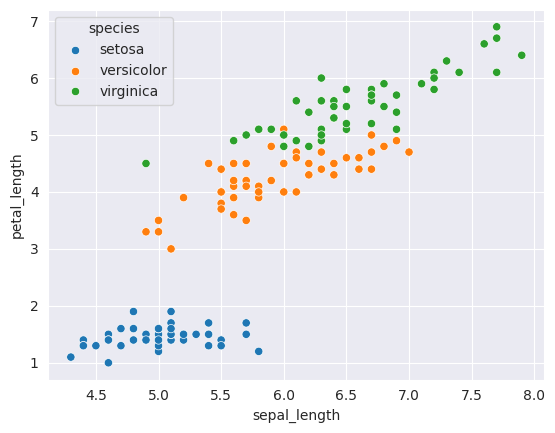

In [3]:
sns.scatterplot(x='sepal_length',y='petal_length',data=iris_df,hue='species')

In [4]:
num_cols=["sepal_length","sepal_width","petal_length","petal_width"]
X=iris_df[num_cols]
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
from sklearn.cluster import KMeans

In [6]:
model=KMeans(n_clusters=3,random_state=42)
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [7]:
model.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [8]:
preds=model.predict(X)

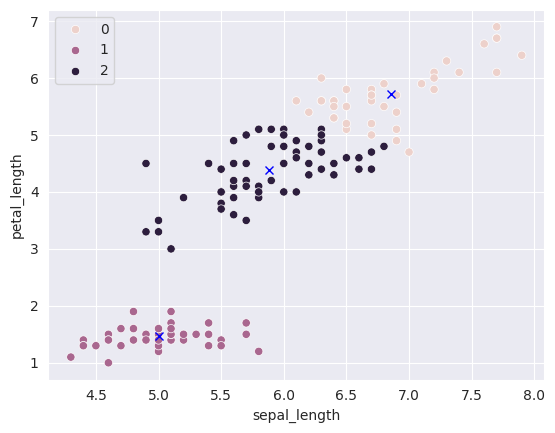

In [9]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds);
centers_x, centers_y = model.cluster_centers_[:,0], model.cluster_centers_[:,2]
plt.plot(centers_x, centers_y, 'xb')

In [10]:
model.inertia_

78.85566582597727

In [11]:
model=KMeans(n_clusters=6,random_state=42)
model.fit(X)

KMeans(n_clusters=6, random_state=42)

In [12]:
preds=model.predict(X)


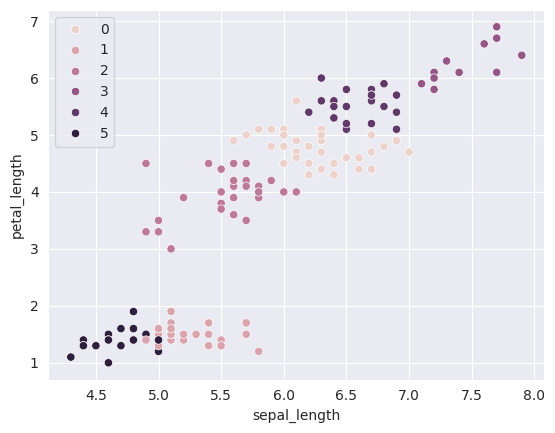

In [13]:
sns.scatterplot(data=X,x='sepal_length',y='petal_length',hue=preds);

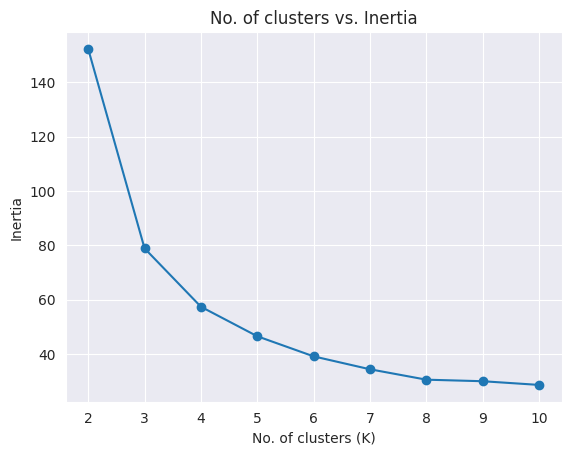

In [14]:
options=range(2,11)
inertias=[]
for n_clusters in options:
    model=KMeans(n_clusters,random_state=42).fit(X)
    inertias.append(model.inertia_)
plt.title("No. of clusters vs. Inertia")
plt.plot(options,inertias,'-o')
plt.xlabel('No. of clusters (K)')
plt.ylabel('Inertia');

In [16]:
from sklearn.cluster import DBSCAN

In [45]:
model=DBSCAN(eps=0.5,min_samples=10)
model.fit(X)

DBSCAN(min_samples=10)

In [46]:
model.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1,
       -1,  1,  1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1,
       -1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

In [47]:
model.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        16,  17,  19,  20,  21,  23,  25,  26,  27,  28,  29,  30,  31,
        34,  35,  36,  37,  38,  39,  40,  42,  43,  45,  46,  47,  48,
        49,  51,  54,  55,  61,  63,  67,  69,  71,  74,  78,  82,  83,
        86,  88,  89,  91,  92,  94,  95,  96,  97,  99, 104, 111, 112,
       116, 123, 126, 127, 138, 140, 147])

<Axes: xlabel='sepal_length', ylabel='petal_length'>

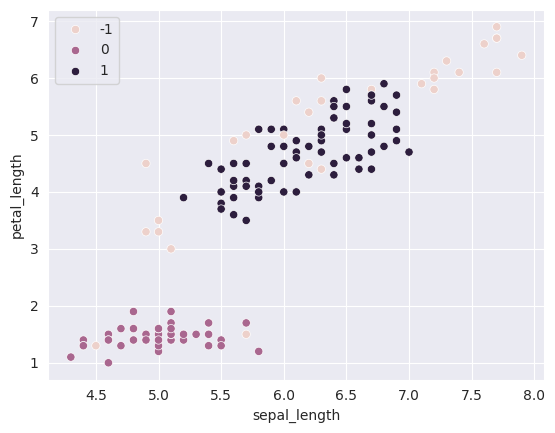

In [48]:
sns.scatterplot(data=X,x='sepal_length',y='petal_length',hue=model.labels_)

In [49]:
from sklearn.decomposition import PCA

In [50]:
pca=PCA(n_components=2)

In [55]:
pca.fit(X)

PCA(n_components=2)

In [58]:
pca.components_
#first line and second line are perpendicular in this case

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [59]:
transformed=pca.transform(X)

<Axes: >

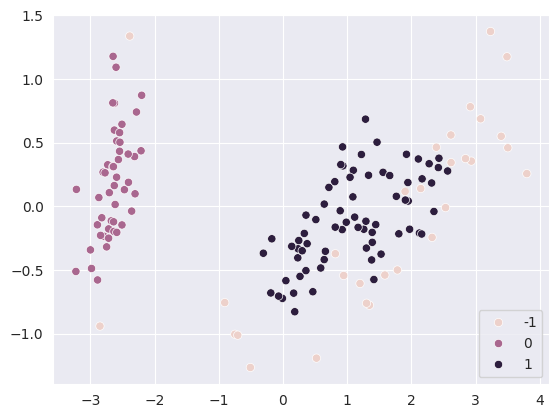

In [63]:
sns.scatterplot(x=transformed[:,0],y=transformed[:,1],hue=model.labels_)

In [76]:
from sklearn.manifold import TSNE

In [77]:
tsne=TSNE(n_components=2)

In [78]:
transformed=tsne.fit_transform(X)

<Axes: >

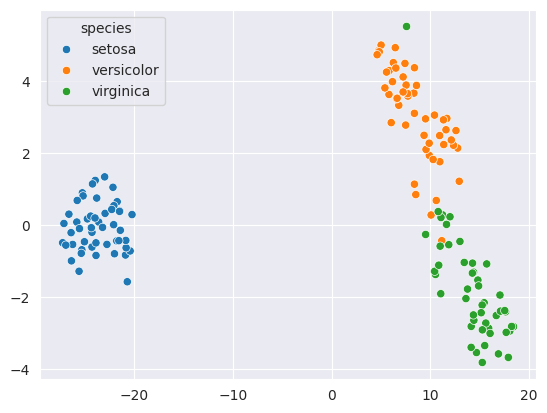

In [79]:
sns.scatterplot(x=transformed[:,0],y=transformed[:,1],hue=iris_df['species'])